In [1]:
import sqlite3
import random


products = {
    "Coffee": 5.0,
    "Tea": 3.0,
    "Juice": 4.5,
    "Smoothie": 6.0,
    "Soda": 2.5,
    "Water": 1.0
}


conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

# Create the sales table
cursor.execute("DROP TABLE IF EXISTS sales")
cursor.execute("""
    CREATE TABLE sales (
        product TEXT,
        quantity INTEGER,
        price REAL
    )
""")


sales_data = []
for _ in range(300):
    product = random.choice(list(products.keys()))
    base_price = products[product]
    quantity = random.randint(1, 20)

    price = round(base_price + random.uniform(-0.5, 0.5), 2)
    sales_data.append((product, quantity, price))

# Insert data into the table
cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sales_data)

# Commit and close connection
conn.commit()
conn.close()

print("✅ sales_data.db created with 300+ rows!")


✅ sales_data.db created with 300+ rows!


In [6]:
import pandas as pd
import matplotlib.pyplot as plt


conn = sqlite3.connect("sales_data.db")


query = """
SELECT
    product,
    SUM(quantity) AS total_qty,
    SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
"""


df = pd.read_sql_query(query, conn)


print(df)




conn.close()


    product  total_qty  revenue
0    Coffee        587  2926.75
1     Juice        513  2307.26
2  Smoothie        464  2712.24
3      Soda        524  1309.69
4       Tea        476  1426.81
5     Water        401   430.16


📄 Sample Data:
  product  quantity  price
0    Soda         5   2.50
1   Water         5   1.06
2   Juice        17   4.55
3   Water        18   0.97
4    Soda        10   2.80


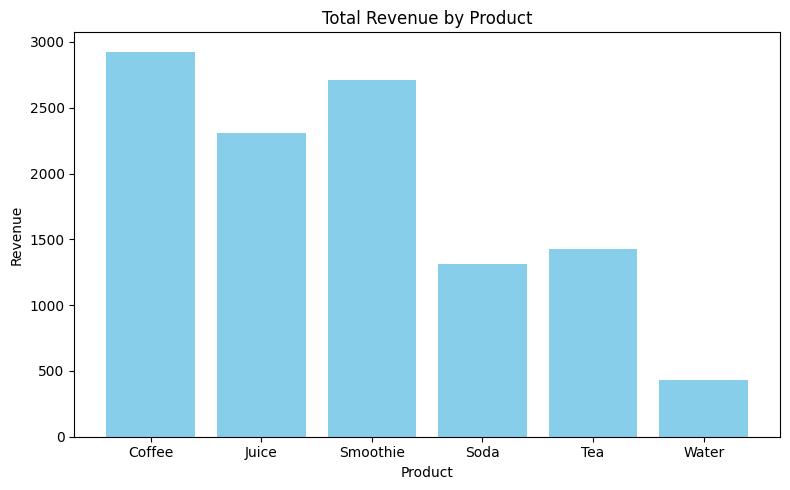

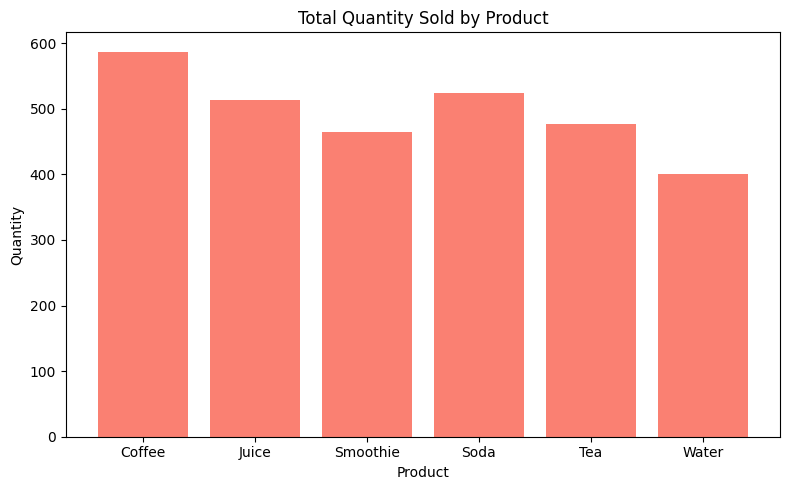

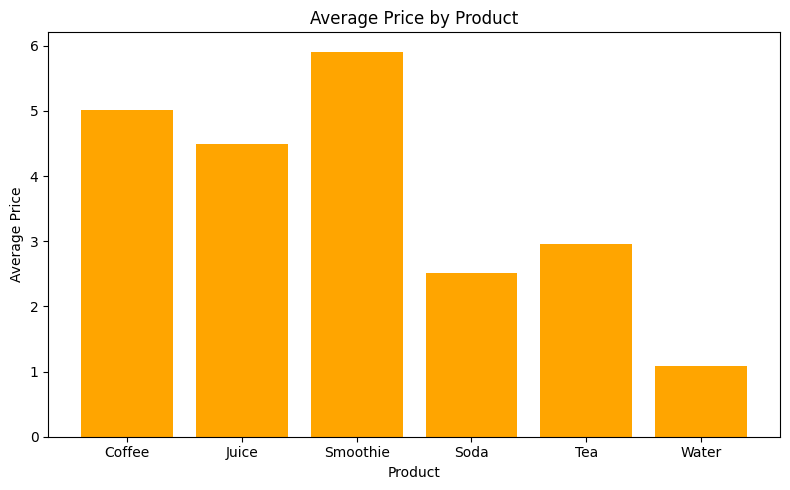

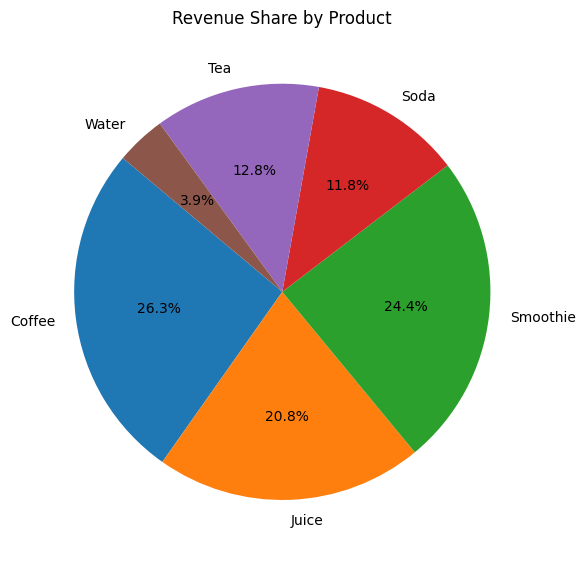

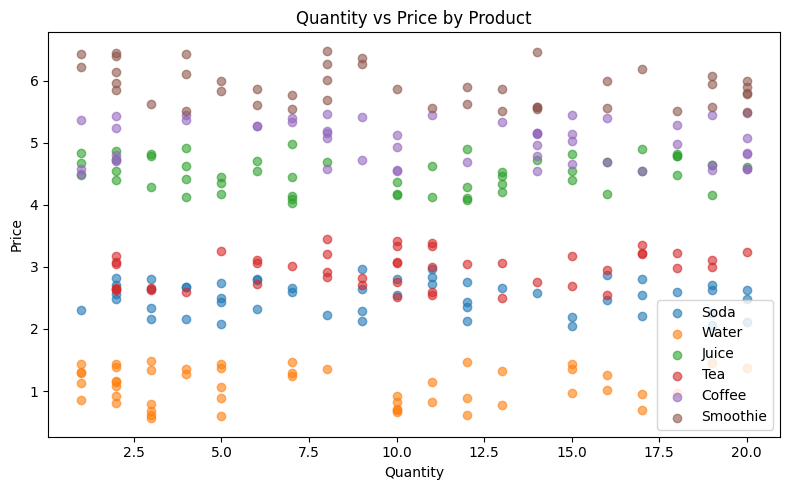

In [5]:

conn = sqlite3.connect("sales_data.db")


df = pd.read_sql_query("SELECT * FROM sales", conn)


print("📄 Sample Data:")
print(df.head())


conn.close()


# 1. Total Revenue per Product

revenue_df = df.copy()
revenue_df['revenue'] = revenue_df['quantity'] * revenue_df['price']
revenue_summary = revenue_df.groupby('product')['revenue'].sum().reset_index()

plt.figure(figsize=(8,5))
plt.bar(revenue_summary['product'], revenue_summary['revenue'], color='skyblue')
plt.title("Total Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig("revenue_by_product.png")
plt.show()


# 2. Total Quantity Sold per Product

quantity_summary = df.groupby('product')['quantity'].sum().reset_index()

plt.figure(figsize=(8,5))
plt.bar(quantity_summary['product'], quantity_summary['quantity'], color='salmon')
plt.title("Total Quantity Sold by Product")
plt.xlabel("Product")
plt.ylabel("Quantity")
plt.tight_layout()
plt.savefig("quantity_by_product.png")
plt.show()


# 3. Average Price per Product

avg_price_summary = df.groupby('product')['price'].mean().reset_index()

plt.figure(figsize=(8,5))
plt.bar(avg_price_summary['product'], avg_price_summary['price'], color='orange')
plt.title("Average Price by Product")
plt.xlabel("Product")
plt.ylabel("Average Price")
plt.tight_layout()
plt.savefig("avg_price_by_product.png")
plt.show()


# 4. Pie Chart of Total Revenue Share

plt.figure(figsize=(6,6))
plt.pie(revenue_summary['revenue'], labels=revenue_summary['product'], autopct='%1.1f%%', startangle=140)
plt.title("Revenue Share by Product")
plt.tight_layout()
plt.savefig("revenue_share_pie.png")
plt.show()


# 5. Scatter Plot: Quantity vs Price (Colored by Product)

plt.figure(figsize=(8,5))
for product in df['product'].unique():
    subset = df[df['product'] == product]
    plt.scatter(subset['quantity'], subset['price'], label=product, alpha=0.6)

plt.title("Quantity vs Price by Product")
plt.xlabel("Quantity")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.savefig("quantity_vs_price_scatter.png")
plt.show()
